In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import *

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("taxi_trip_pricing.csv")

# Handle Missing Values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#Encode Categorical Variables
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])



/tmp/ipykernel_14987/3712568293.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
df.head(6)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3.0,1,0,3.56,0.80,0.32,53.82,36.2624
1,47.59,0,0,1.0,0,0,3.52,0.62,0.43,40.57,50.0745
2,36.87,1,1,1.0,0,0,2.70,1.21,0.15,37.27,52.9032
3,30.33,1,0,4.0,1,0,3.48,0.51,0.15,116.81,36.4698
4,25.83,1,0,3.0,0,0,2.93,0.63,0.32,22.64,15.6180
5,8.64,0,1,2.0,2,0,2.55,1.71,0.48,89.33,60.2028


In [9]:
df.shape

(1000, 11)

In [10]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [11]:
#Separate Features & Target
X = df.drop("Trip_Price", axis=1)
y = df["Trip_Price"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 10)
X_test : (200, 10)
y_train: (800,)
y_test : (200,)


In [13]:
knn_model =KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=7)

In [14]:
svr_model = SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
svr_model.fit(X_train, y_train)

SVR(C=100)

In [35]:
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [16]:
y_pred_knn = knn_model.predict(X_test)
y_pred_svr = svr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

In [19]:
def regressor(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2_score(y_true, y_pred)
    }

In [20]:
results = []
results.append(regressor("KNN", y_test, y_pred_knn))
results.append(regressor("SVR", y_test, y_pred_svr))
results.append(regressor("Decision Tree", y_test, y_pred_dt))

results_df = pd.DataFrame(results)
print(results_df)

           Model        MAE         MSE       RMSE  R2 Score
0            KNN  12.220125  246.297462  15.693867  0.703513
1            SVR  11.455025  211.634994  14.547680  0.745239
2  Decision Tree   9.205115  134.232503  11.585875  0.838414


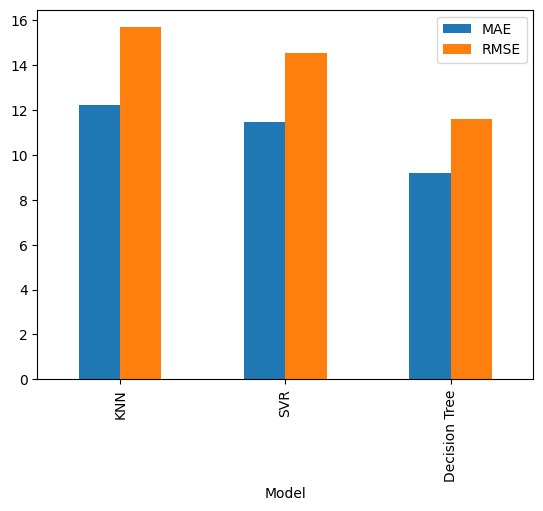

In [22]:
results_df.plot(x="Model", y=["MAE", "RMSE"], kind="bar")
plt.show()

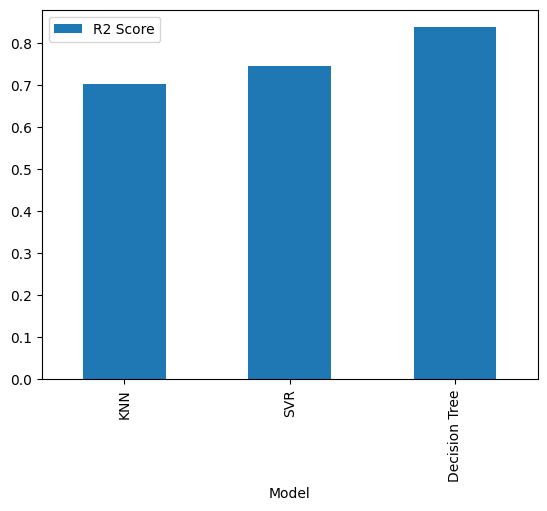

In [37]:
results_df.plot(x="Model", y="R2 Score", kind="bar")
plt.show()

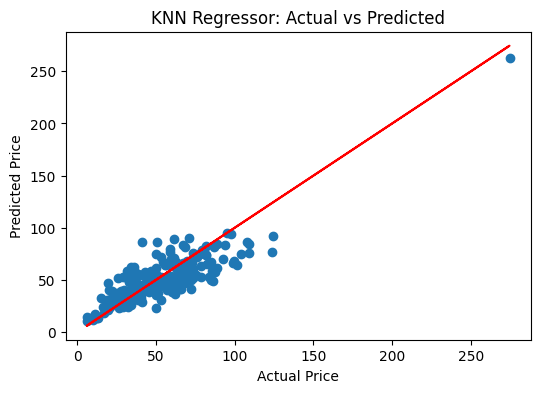

In [28]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regressor: Actual vs Predicted")
plt.plot(y_test, y_test, color='red')
plt.show()

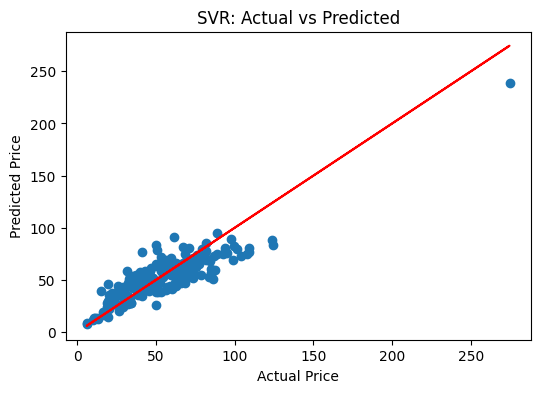

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted")
plt.plot(y_test, y_test, color='red')
plt.show()

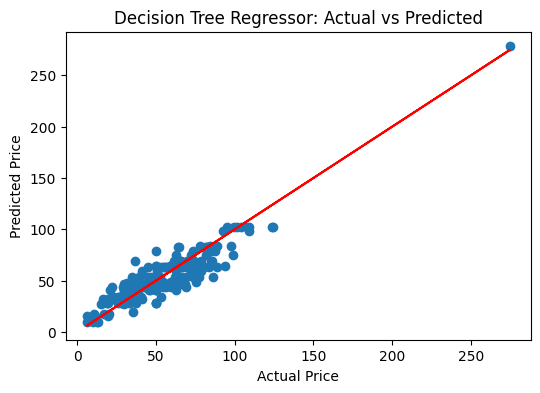

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regressor: Actual vs Predicted")
plt.plot(y_test, y_test, color='red')
plt.show()

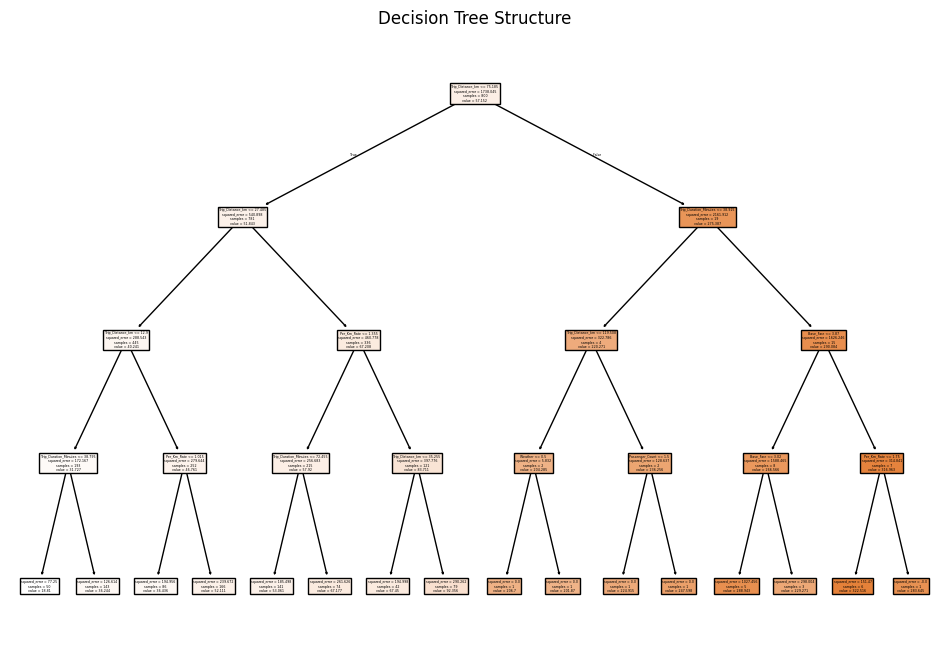

In [38]:
plt.figure(figsize=(12,8))
plot_tree(dt_model, filled=True, feature_names=X.columns)
plt.title("Decision Tree Structure")
plt.show()

In [33]:
best_model = results_df.sort_values("R2 Score", ascending=False).iloc[0]
print("Best regression model based on R2 Score:")
print(best_model)

Best regression model based on R2 Score:
Model       Decision Tree
MAE              9.205115
MSE            134.232503
RMSE            11.585875
R2 Score         0.838414
Name: 2, dtype: object
